In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df=pd.read_csv('ushape.csv', header=None)
df.columns = ['feature1', 'feature2', 'class']
display(df.head())

,feature1,feature2,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


In [6]:
X =df.iloc[:,0:2].values
y=df.iloc[:,-1].values

In [7]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [9]:
model =Sequential()
model.add(Dense(2, activation='tanh', input_dim=2))
model.add(Dense(2, activation='tanh',input_dim=2))
model.add(Dense(2, activation='sigmoid',input_dim=2))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21 (84.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.get_weights()

[array([[-1.0360624 ,  0.4623816 ],
        [-0.40901673, -1.0545373 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.87754595,  0.80427635],
        [-0.69737774, -0.71297616]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.70501184,  0.6334845 ],
        [-0.19839168,  0.21450663]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.22358632],
        [ 0.76384294]], dtype=float32),
 array([0.], dtype=float32)]

In [11]:
initial_weights =model.get_weights()

In [15]:
# Get initial weights from the model
initial_weights = model.get_weights()

# Reinitialize weights manually
initial_weights[0] = np.random.randn(model.get_weights()[0].shape[0], model.get_weights()[0].shape[1]) * 0.01
initial_weights[1] = np.zeros(model.get_weights()[1].shape)

initial_weights[2] = np.random.randn(model.get_weights()[2].shape[0], model.get_weights()[2].shape[1]) * 0.01
initial_weights[3] = np.zeros(model.get_weights()[3].shape)

initial_weights[4] = np.random.randn(model.get_weights()[4].shape[0], model.get_weights()[4].shape[1]) * 0.01
initial_weights[5] = np.zeros(model.get_weights()[5].shape)

initial_weights[6] = np.random.randn(model.get_weights()[6].shape[0], model.get_weights()[6].shape[1]) * 0.01
initial_weights[7] = np.zeros(model.get_weights()[7].shape)

# Set the new initialized weights back to the model
model.set_weights(initial_weights)

In [14]:
model.get_weights()

[array([[0.01377315, 0.00771913],
        [0.005016  , 0.01089639]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.00323287,  0.01538907],
        [ 0.01256977, -0.02344265]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.01878017,  0.00377627],
        [ 0.00827423, -0.00794744]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.00412766],
        [0.01001721]], dtype=float32),
 array([0.], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


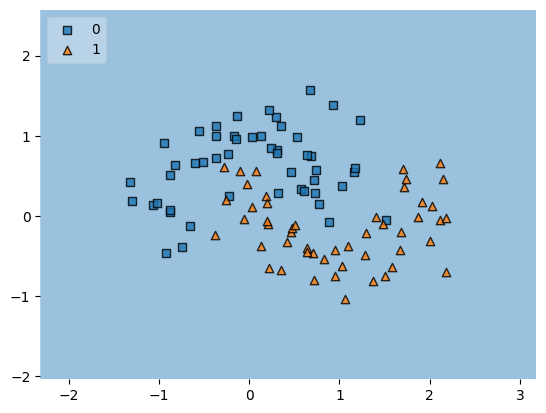

In [18]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X, y.astype('int'),clf = model, legend=2)  # 50% ,50% percent accuracy bht kam hai
plt.show()